### Solving the ODE :

$$ y' + y^2 = 0 $$

with IC :

$$ y(0) = 1 $$

### Exact Solution :

$$ y = \dfrac{1}{1+x} $$

In [31]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [32]:
# domain
N = 101
x = torch.linspace(0,2,N,requires_grad=True).reshape(-1,1)

In [33]:
# Model
model = nn.Sequential(
    nn.Linear(1,20),
    nn.Tanh(),
    nn.Linear(20,20),
    nn.Tanh(),
    nn.Linear(20,1)
)

In [34]:
# Loss function
def Loss(model,x):
    y = model(x)

    # autograds
    dydx = torch.autograd.grad(
        outputs=y,
        inputs=x,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]

    x0 = torch.tensor([0.0],requires_grad=True).reshape(-1,1)
    y0 = model(x0)

    # loss terms
    loss = (y0-1)**2 + torch.mean((dydx+y**2)**2)
    return loss

In [35]:
# optimizer
optim = torch.optim.Adam(model.parameters(),lr = 0.01)

In [36]:
# training the PINN
N_epochs = 10000
loss_arr = []
for epoch in range(N_epochs):
    # feed forward and loss
    loss = Loss(model,x)
    loss_arr.append(loss.item())

    # optimization
    loss.backward()
    optim.step()
    optim.zero_grad()

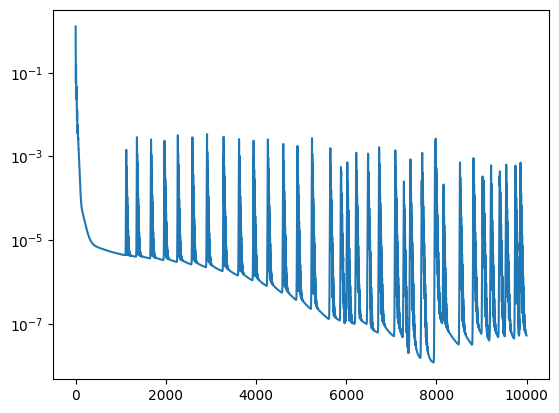

In [37]:
# loss visualisation
plt.semilogy(loss_arr)
plt.show()

In [38]:
# exact function
y_exact = 1/(1+x)

# PINN function
with torch.no_grad():
    y_PINN = model(x)

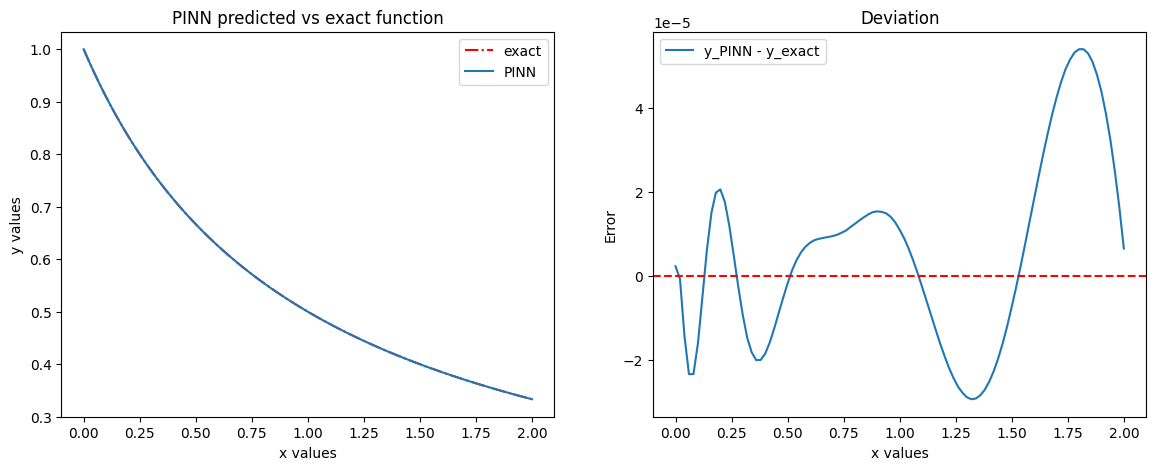

In [40]:
# comparing the PINN against the exact function
plt.figure(figsize = (14,5))

plt.subplot(1,2,1)
plt.plot(x.flatten().detach(),y_exact.flatten().detach(),c = 'red',ls = '-.',label = 'exact')
plt.plot(x.flatten().detach(),y_PINN.flatten().detach(),label = 'PINN')
plt.legend()
plt.title("PINN predicted vs exact function")
plt.xlabel("x values")
plt.ylabel("y values")

plt.subplot(1,2,2)
plt.plot(x.flatten().detach(),(y_PINN-y_exact).flatten().detach(),label = f'y_PINN - y_exact')
plt.axhline(0,ls = '--',c = 'red')
plt.legend()
plt.title("Deviation")
plt.xlabel("x values")
plt.ylabel("Error")
plt.show()